In [1]:
pip install torch transformers scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


🚀 硬體加速: Apple Silicon GPU (MPS)
🚀 [Start] MacBERT (Standard Protocol)...
   Train Full: 18821 | Test Final: 4706

🥊 Step 1: 5-Fold Cross Validation on Train Set...
   Running Fold 1/5...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-macbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Running Fold 2/5...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-macbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Running Fold 3/5...

...

   Running Fold 5/5...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-macbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✅ 5-Fold CV 平均 F1: 0.3828

🚀 Step 2: Final Training (Full Train Set)...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-macbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Epoch 1: Loss 0.6115 | Acc 0.6626
   Epoch 2: Loss 0.5360 | Acc 0.7100
   Epoch 3: Loss 0.4665 | Acc 0.7610

🏆 【 MacBERT 模型訓練結果：五大指標成績表 】
Metric          | Score     
------------------------------
Accuracy        | 0.6895
Precision       | 0.5614
Recall          | 0.5064
F1-Score        | 0.5325
AUROC           | 0.7387
------------------------------
10-Fold F1      | 0.3828


📌 模型詳細報告：hfl/chinese-macbert-base
--------------------------------------------------------------------------------
【 三大指標詳細成績表 】
              precision    recall  f1-score   support

           0     0.7484    0.7878    0.7676      3063
           1     0.5614    0.5064    0.5325      1643

    accuracy                         0.6895      4706
   macro avg     0.6549    0.6471    0.6500      4706
weighted avg     0.6831    0.6895    0.6855      4706

--------------------------------------------------------------------------------
【 混淆矩陣圖 】


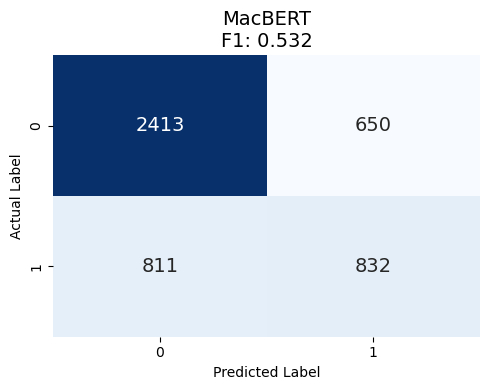

In [2]:
import pandas as pd
import numpy as np
import torch
import time
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW 
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned.csv'
MODEL_NAME = 'hfl/chinese-macbert-base' # MacBERT
MAX_LEN = 256         
BATCH_SIZE = 32       
EPOCHS = 3            
LEARNING_RATE = 2e-5  
CV_FOLDS = 5         
SEED = 42

# 偵測加速
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🚀 硬體加速: Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("🚀 硬體加速: NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(SEED)

# ==========================================
# 🔧 資料集與函數
# ==========================================
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_epoch(model, data_loader, optimizer, device, scheduler):
    model = model.train()
    losses = []
    correct_predictions = 0
    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return correct_predictions.float() / len(data_loader.dataset), np.mean(losses)

def eval_model(model, data_loader, device):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1]
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    accuracy = correct_predictions.float() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    return accuracy.item(), avg_loss, all_preds, all_labels, all_probs

# ==========================================
# 🚀 主流程 (標準 CV + Final Test)
# ==========================================
if __name__ == '__main__':
    print(f"🚀 [Start] MacBERT (Standard Protocol)...")
    if not os.path.exists(INPUT_CSV): exit()
    df = pd.read_csv(INPUT_CSV)
    if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)
    df = df.dropna(subset=['title_clean', 'label'])
    df['label'] = df['label'].astype(int)
    
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    X = df['title_clean'].values
    y = df['label'].values
    
    # 1. 切分 80/20
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    print(f"   Train Full: {len(X_train_full)} | Test Final: {len(X_test)}")
    
    # 2. 5-Fold CV (驗證穩定性)
    print(f"\n🥊 Step 1: 5-Fold Cross Validation on Train Set...")
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    fold_f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        print(f"   Running Fold {fold+1}/{CV_FOLDS}...", end="\r")
        X_tr_fold, y_tr_fold = X_train_full[train_idx], y_train_full[train_idx]
        X_val_fold, y_val_fold = X_train_full[val_idx], y_train_full[val_idx]
        
        train_ds = NewsDataset(X_tr_fold, y_tr_fold, tokenizer, MAX_LEN)
        val_ds = NewsDataset(X_val_fold, y_val_fold, tokenizer, MAX_LEN)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
        
        model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
        optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
        scheduler = get_linear_schedule_with_warmup(optimizer, 0, len(train_loader)*EPOCHS)
        
        # CV 只跑 1 Epoch 以節省時間 (與原流程一致)
        train_epoch(model, train_loader, optimizer, DEVICE, scheduler)
        _, _, preds, labels, _ = eval_model(model, val_loader, DEVICE)
        fold_f1_scores.append(f1_score(labels, preds, average='binary'))
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
    print(f"   ✅ 5-Fold CV 平均 F1: {np.mean(fold_f1_scores):.4f}")

    # 3. Final Training (使用完整 80%)
    print(f"\n🚀 Step 2: Final Training (Full Train Set)...")
    full_train_ds = NewsDataset(X_train_full, y_train_full, tokenizer, MAX_LEN)
    test_ds = NewsDataset(X_test, y_test, tokenizer, MAX_LEN)
    full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
    
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, len(full_train_loader)*EPOCHS)
    
    for epoch in range(EPOCHS):
        acc, loss = train_epoch(model, full_train_loader, optimizer, DEVICE, scheduler)
        print(f"   Epoch {epoch+1}: Loss {loss:.4f} | Acc {acc:.4f}")

    # 4. Final Evaluation
    test_acc, test_loss, test_preds, test_labels, test_probs = eval_model(model, test_loader, DEVICE)
    test_f1 = f1_score(test_labels, test_preds, average='binary')
    test_prec = precision_score(test_labels, test_preds, average='binary')
    test_rec = recall_score(test_labels, test_preds, average='binary')
    test_auroc = roc_auc_score(test_labels, test_probs)

    # 輸出結果
    print("\n" + "="*60)
    print(f"🏆 【 MacBERT 模型訓練結果：五大指標成績表 】")
    print("="*60)
    print(f"{'Metric':<15} | {'Score':<10}")
    print("-" * 30)
    print(f"{'Accuracy':<15} | {test_acc:.4f}")
    print(f"{'Precision':<15} | {test_prec:.4f}")
    print(f"{'Recall':<15} | {test_rec:.4f}")
    print(f"{'F1-Score':<15} | {test_f1:.4f}")
    print(f"{'AUROC':<15} | {test_auroc:.4f}")
    print("-" * 30)
    print(f"{'10-Fold F1':<15} | {np.mean(fold_f1_scores):.4f}")
    print("\n")
    print("="*80)
    print(f"📌 模型詳細報告：{MODEL_NAME}")
    print("-" * 80)
    print("【 三大指標詳細成績表 】")
    print(classification_report(test_labels, test_preds, digits=4))
    print("-" * 80)
    print(f"【 混淆矩陣圖 】")
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
    plt.title(f'MacBERT\nF1: {test_f1:.3f}', fontsize=14)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()